In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11001
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  236.49617000156042
RUN  2 , total integrated cost =  175.06216006517386
RUN  3 , total integrated cost =  117.19950337370298
RUN  4 , total integrated cost =  98.36913661752952
RUN  5 , total integrated cost =  82.01163808722133
RUN  6 , total integrated cost =  74.51416460361179
RUN  7 , total integrated cost =  67.75985244677778
RUN  8 , total integrated cost =  63.83707723959185
RUN  9 , total integrated cost =  60.501426966086
RUN  10 , total integrated cost =  58.07776963197685
RUN  11 , total integrated cost =  55.97782379824624
RUN  12 , total integrated cost =  54.37076765013206
RUN  13 , total integrated cost =  53.011888818819834
RUN  14 , total integrated cost =  51.82465337549476
RUN  15 , total integrated cost =  50.81566704917757
RUN  16 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  473 , total integrated cost =  27.54072571636919
Improved over  473  iterations in  59.250824235379696  seconds by  99.7931047695358  percent.
Problem in initial value trasfer:  Vmean_exc -65.75830709135866 -65.7638176417662
weight =  4833.3641996307815
set cost params:  1.0 4833.3641996307815 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13200.849366978115
Gradient descend method:  None
RUN  1 , total integrated cost =  12785.428553605389
RUN  2 , total integrated cost =  12784.74391679669
RUN  3 , total integrated cost =  12784.739229367946
RUN  4 , total integrated cost =  12784.738266573555
RUN  5 , total integrated cost =  12784.736608066278
RUN  6 , total integrated cost =  12784.545172929826
RUN  7 , total integrated cost =  12784.24911440158
RUN  8 , total integrated cost =  12784.245680721751
RUN  9 , total integrated cost =  12784.245077338734
RUN  10 , total integrated cost =  12784.244814960226
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  34 , total integrated cost =  12781.478372219084
Improved over  34  iterations in  3.211320135742426  seconds by  3.1768485731538334  percent.
Problem in initial value trasfer:  Vmean_exc -60.341995758992496 -60.36169038619746
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  441.5203354059718
RUN  2 , total integrated cost =  305.0889520481938
RUN  3 , total integrated cost =  201.27771805493802
RUN  4 , total integrated cost =  172.26934064173753
RUN  5 , total integrated cost =  147.53012325078984
RUN  6 , total integrated cost =  136.00870147546954
RUN  7 , total integrated cost =  126.67257280358864
RUN  8 , total integrated cost =  121.21706943720227
RUN  9 , total integrated cost =  116.9197603349192
RUN  10 , total integrated cost =  113.91832330907168
RUN 

...

RUN  6 , total integrated cost =  9878.511020220487
Control only changes marginally.
RUN  6 , total integrated cost =  9878.511020220487
Improved over  6  iterations in  0.7375721875578165  seconds by  2.019254603214222  percent.
Problem in initial value trasfer:  Vmean_exc -65.08265868392482 -65.14519558550451
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  482.9968141446041
RUN  2 , total integrated cost =  325.9208927798826
RUN  3 , total integrated cost =  212.0172154933582
RUN  4 , total integrated cost =  180.33858552611164
RUN  5 , total integrated cost =  156.70257140320584
RUN  6 , total integrated cost =  145.55727240889917
RUN  7 , total integrated cost =  136.75041253677634
RUN  8 , total integrated cost =  131.41465165438302
RUN  9 , total integrated cost =  127.27084568929914
RUN  10 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  296 , total integrated cost =  75.04830911764219
Improved over  296  iterations in  20.50227439776063  seconds by  99.67970189269319  percent.
Problem in initial value trasfer:  Vmean_exc -67.02589289207934 -67.0570903919661
weight =  3122.0915053429285
set cost params:  1.0 3122.0915053429285 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23095.55414113106
Gradient descend method:  None
RUN  1 , total integrated cost =  22092.207776044506
RUN  2 , total integrated cost =  22089.125350597424
RUN  3 , total integrated cost =  22088.999209420886
RUN  4 , total integrated cost =  22088.736813480984
RUN  5 , total integrated cost =  22088.614372160282
RUN  6 , total integrated cost =  22088.14535219843
RUN  7 , total integrated cost =  22087.74544379304
RUN  8 , total integrated cost =  22084.06164537156
RUN  9 , total integrated cost =  22081.187468402837
RUN  10 , total integrated cost =  22081.12179515793
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  65 , total integrated cost =  22067.400761837012
Improved over  65  iterations in  7.282574577257037  seconds by  4.451737217523615  percent.
Problem in initial value trasfer:  Vmean_exc -57.93144561404193 -57.92363907147462


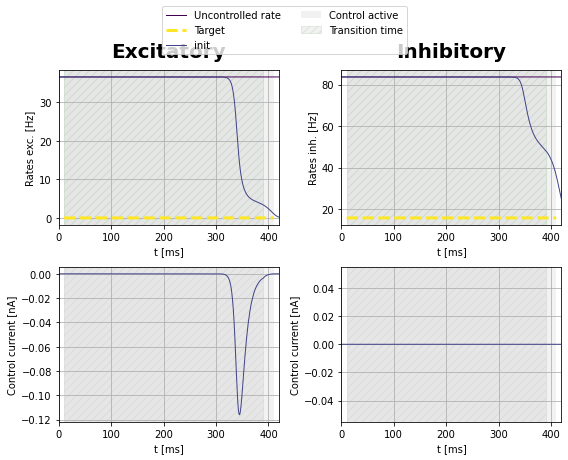

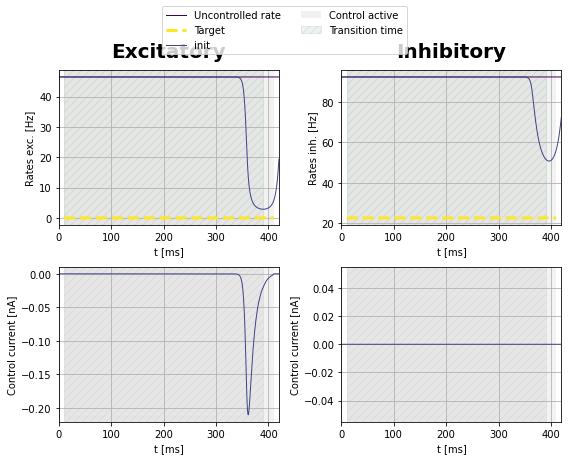

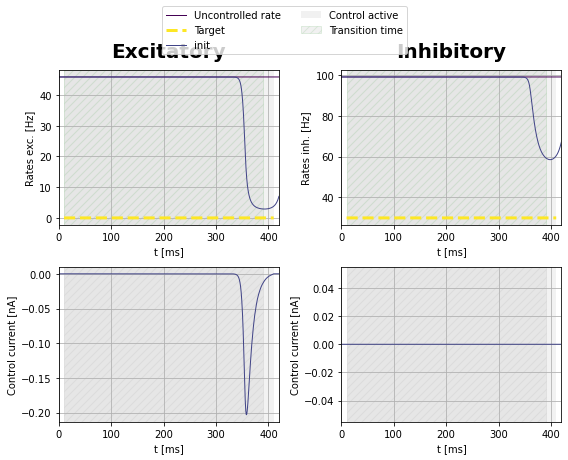

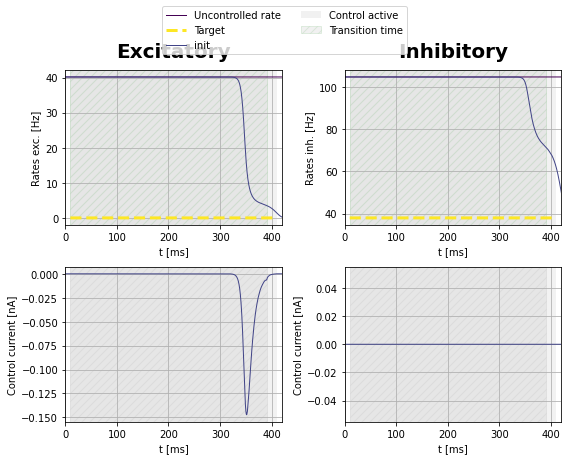

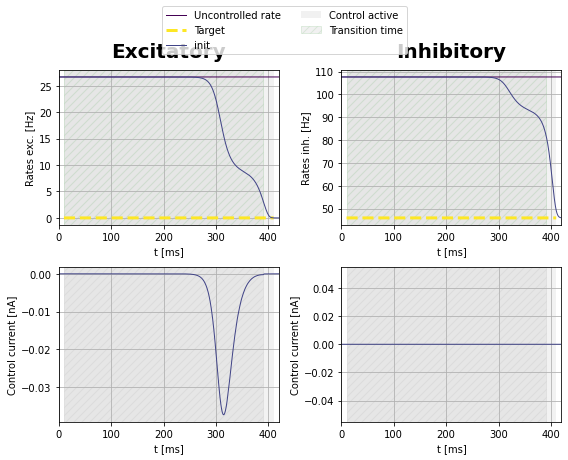

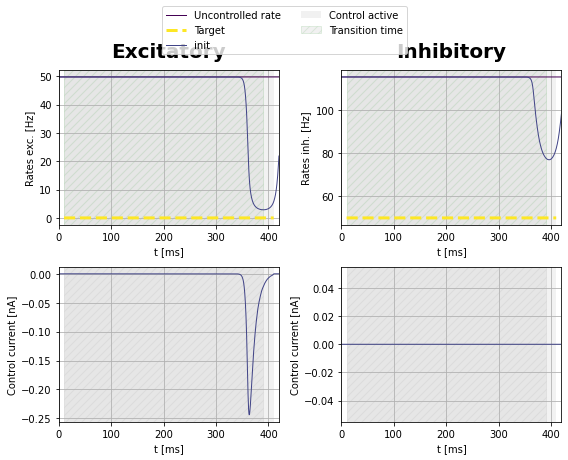

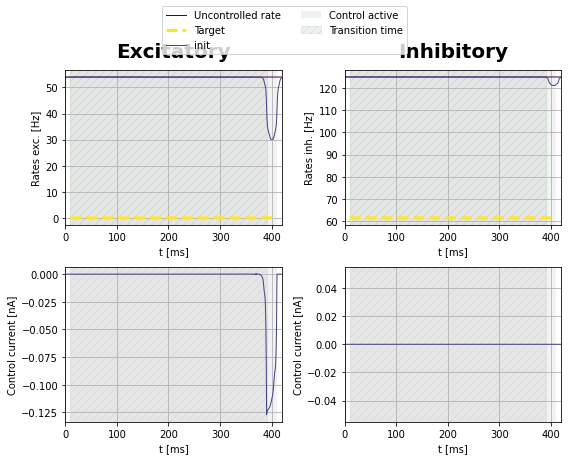

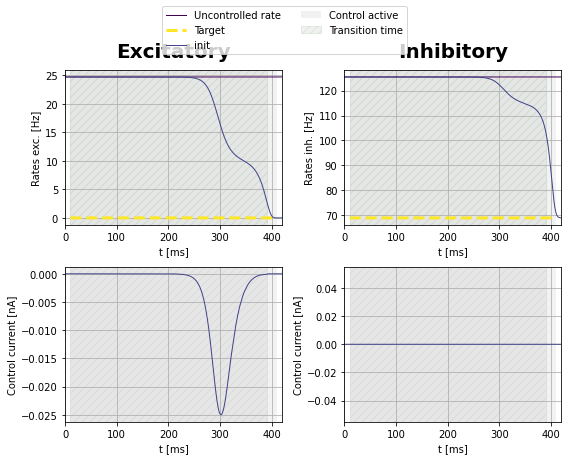

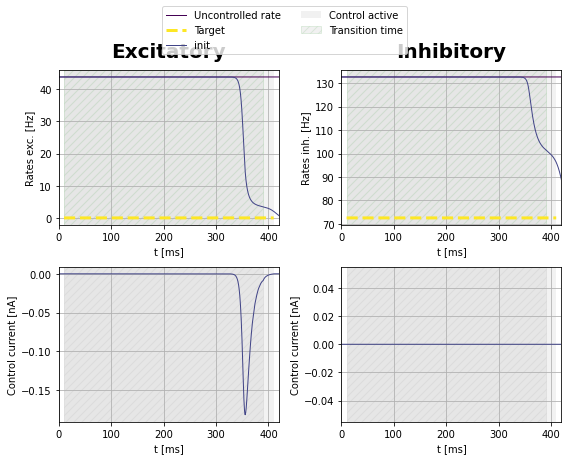

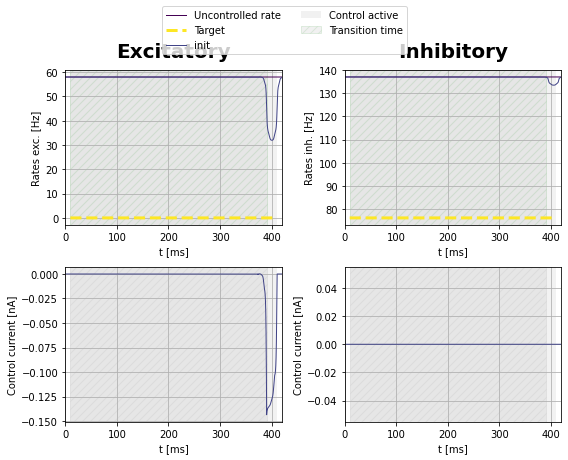

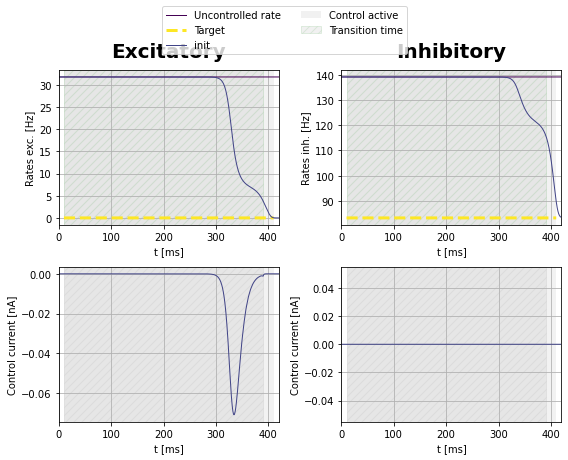

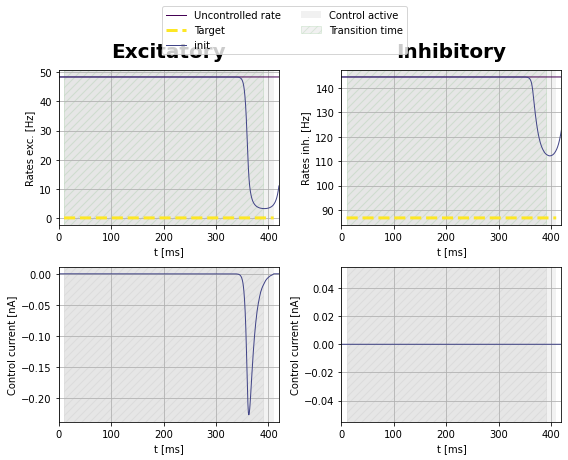

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
[0, 11] []
closest index  11
s

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  358 , total integrated cost =  69.60979843145927
Improved over  358  iterations in  26.20233510993421  seconds by  99.67341724235895  percent.
Problem in initial value trasfer:  Vmean_exc -64.16448244395993 -64.17494548369068
weight =  3098.0089117114144
set cost params:  1.0 3098.0089117114144 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21248.796218865376
Gradient descend method:  None
RUN  1 , total integrated cost =  20335.768451881824
RUN  2 , total integrated cost =  20334.304984339964
RUN  3 , total integrated cost =  20333.993329191275
RUN  4 , total integrated cost =  20333.617293497282
RUN  5 , total integrated cost =  20333.49382369459
RUN  6 , total integrated cost =  20333.254828206995
RUN  7 , total integrated cost =  20333.118215862123
RUN  8 , total integrated cost =  20332.340398237196
RUN  9 , total integrated cost =  20331.64862328481
RUN  10 , total integrated cost =  20330.330710836544
RUN  11 , t

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  20314.92102654348
Control only changes marginally.
RUN  30 , total integrated cost =  20314.92102654348
Improved over  30  iterations in  2.23989662155509  seconds by  4.394955755153646  percent.
Problem in initial value trasfer:  Vmean_exc -57.743661717415414 -57.732210172912666
-------  33 0.5000000000000002 0.5250000000000002
found solution for  33
-------  44 0.47500000000000014 0.5750000000000003
found solution for  44
-------  55 0.4250000000000001 0.6250000000000003
found solution for  55
-------  66 0.5250000000000001 0.6500000000000004
[0, 11, 33, 44, 55] []
closest index  44
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24405.07995787088
Gradient descend method:  None
RUN  1 , total integrated cost =  529.0110652374133
RUN  2 , total integrated cost =  367.29264762063724
RUN  3 , total integrated cost =  235.94280136783522
RUN  4 , total integrated cost =  203.337

...

Control only changes marginally.
RUN  666 , total integrated cost =  18533.039642561504
Improved over  666  iterations in  45.60058619081974  seconds by  34.95232271730538  percent.
Problem in initial value trasfer:  Vmean_exc -56.68604250780375 -56.687996843267115
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
[0, 11, 33, 44, 55, 77, 99, 110, 132, 143, 22, 66] [110, 143, 132, 99, 77, 55, 44, 66, 33, 22, 11]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33618.266211604714
Gradient descend method:  None
RUN  1 , total integrated cost =  720.186269535621
RUN  2 , total integrated cost =  490.9345564723932
RUN  3 , total integrated cost =  320.30669997571
RUN  4 , total integrated cost =  276.3862265833787
RUN  5 , total integrated cost =  239.55292897278426
RUN  6 , total integrated cost = 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  281 , total integrated cost =  140.62447498887116
Improved over  281  iterations in  18.903569927439094  seconds by  99.58170217909593  percent.
Problem in initial value trasfer:  Vmean_exc -62.828085221830435 -62.841902120910625
weight =  2391.650395684416
set cost params:  1.0 2391.650395684416 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32751.42844494782
Gradient descend method:  None
RUN  1 , total integrated cost =  30764.209607395926
RUN  2 , total integrated cost =  30761.472237067785
RUN  3 , total integrated cost =  30759.819709491163
RUN  4 , total integrated cost =  30757.690823929683
RUN  5 , total integrated cost =  30756.2232583673
RUN  6 , total integrated cost =  30754.372346002903
RUN  7 , total integrated cost =  30753.062900443292
RUN  8 , total integrated cost =  30751.25566810253
RUN  9 , total integrated cost =  30749.857379556655
RUN  10 , total integrated cost =  30748.025358832136
RUN  11 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  233 , total integrated cost =  21233.19365714347
Improved over  233  iterations in  16.443836173042655  seconds by  35.168648619908154  percent.
Problem in initial value trasfer:  Vmean_exc -56.69375612512874 -56.69551915406094
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 12
------------------------------------------------------------
found solution:  [0, 11, 33, 44, 55, 77, 99, 110, 132, 143, 22, 66]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004


In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5032.7695865264195
set cost params:  1.0 5032.7695865264195 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13306.385462950557
Gradient descend method:  None
RUN  1 , total integrated cost =  13306.352716571215
RUN  2 , total integrated cost =  13306.35271657117
RUN  3 , total integrated cost =  13306.352716571166


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  13306.352716571166
Control only changes marginally.
RUN  4 , total integrated cost =  13306.352716571166
Improved over  4  iterations in  0.5670666918158531  seconds by  0.00024609522610319345  percent.
Problem in initial value trasfer:  Vmean_exc -60.273441718830476 -60.292826227417805
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  3285.011319302837
set cost params:  1.0 3285.011319302837 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21552.819382902264
Gradient descend method:  None
RUN  1 , total integrated cost =  21333.83134302007
RUN  2 , total integrated cost =  14366.548095078788
RUN  3 , total integrated cost =  14259.39794641636
RUN  4 , total integrated cost =  14245.97013827382
RUN  5 , total integrated cost =  14245.61506256443
RUN  6 , total integrated cost =  14245.615062564415
RUN  7 , total integrated cost =  14245.615062564411


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  14245.61506256441
RUN  9 , total integrated cost =  14245.61506256441
Control only changes marginally.
RUN  9 , total integrated cost =  14245.61506256441
Improved over  9  iterations in  0.8119982182979584  seconds by  33.9037050815478  percent.
Problem in initial value trasfer:  Vmean_exc -56.66864593331663 -56.670396358862504
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  3416.172514677298
set cost params:  1.0 3416.172514677298 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21057.750792229963
Gradient descend method:  None
RUN  1 , total integrated cost =  21057.685256252324
RUN  2 , total integrated cost =  21057.685141457107


...

RUN  1 , total integrated cost =  27371.757799589115
RUN  2 , total integrated cost =  27371.757799589115
Control only changes marginally.
RUN  2 , total integrated cost =  27371.757799589115
Improved over  2  iterations in  0.26554821990430355  seconds by  0.02805941536728085  percent.
Problem in initial value trasfer:  Vmean_exc -56.70362147121308 -56.70369108866411
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
no convergence
weight =  22989.37125871229
set cost params:  1.0 22989.37125871229 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18033.298863492324
Gradient descend method:  None
RUN  1 , total integrated cost =  18028.04522092177
RUN  2 , total integrated cost =  18028.045220921755


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  18028.045220921755
Control only changes marginally.
RUN  3 , total integrated cost =  18028.045220921755
Improved over  3  iterations in  0.3941360842436552  seconds by  0.029133008942721972  percent.
Problem in initial value trasfer:  Vmean_exc -56.68921687697787 -56.68944745077215
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  18381.100982753083
set cost params:  1.0 18381.100982753083 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  31607.869540392174
Gradient descend method:  None
RUN  1 , total integrated cost =  31599.226079294018
RUN  2 , total integrated cost =  31599.225419094433
RUN  3 , total integrated cost =  31599.22541909442
RUN  4 , total integrated cost =  31599.22541909441
RUN  5 , total integrated cost =  31599.225419094408
RUN  6 , total integrated cost =  31599.225419094404


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  31599.225419094404
Control only changes marginally.
RUN  7 , total integrated cost =  31599.225419094404
Improved over  7  iterations in  0.7446000166237354  seconds by  0.02734800359360179  percent.
Problem in initial value trasfer:  Vmean_exc -56.70412254188408 -56.70408943595325
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [False, False], [False, False], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  82.99883739338361
Gradient descend method:  None
RUN  1 , total integrated cost =  23.559217233891783
RUN  2 , total integrated cost =  23.555932324515208
RUN  3 , total integrated cost =  23.555892514134435
RUN  4 , total integrated cost =  23.55587151841333
RUN  5 , total integrated cost =  23.55492016340341
RUN  6 , total integrated cost =  23.553388476602848
RUN  7 , total integrated cost =  23.553344444497377
RUN  8 , total integrated cost =  23.553333068989033
RUN  9 , total integrated cost =  23.553224740812777
RUN  10 , total integrated cost =  23.552700908929285
RUN  11 , total integrated cost =  23.552646523551843
RUN  12 , total integrated cost =  23.55263778928808
RUN  13 , total integrated cost =  23.55260410412326
RUN  14 , total integrated cost =  23.55140769926645
RUN  15 , total integrated cost =  23.55078829175586
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  295 , total integrated cost =  23.333440829870973
Improved over  295  iterations in  94.14282284118235  seconds by  71.88702689981169  percent.
Problem in initial value trasfer:  Vmean_exc -65.8970584225392 -65.90070979932287
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  270.65662283993646
Gradient descend method:  HS
RUN  1 , total integrated cost =  267.7054779515272
RUN  2 , total integrated cost =  267.603256292179
RUN  3 , total integrated cost =  266.99935298904046
RUN  4 , total integrated cost =  266.99932938938105
RUN  5 , total integrated cost =  266.28052157770924
RUN  6 , total integrated cost =  266.06238223665827
RUN  7 , total integrated cost =  265.98794202993736
RUN  8 , total integrated cost =  265.90276476479096
RUN  9 , total integrated cost =  265.78628446822785
RUN  10 , total integrated cost =  265.78623687805873
RUN  11 , total integrated cost =  265.691

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  72 , total integrated cost =  264.46762744568696
Improved over  72  iterations in  14.957341535016894  seconds by  2.2866595058010546  percent.
Problem in initial value trasfer:  Vmean_exc -65.41060130285754 -65.42082879965557
weight =  5032.294962979429
set cost params:  1.0 5032.294962979429 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13262.367312060253
Gradient descend method:  None
RUN  1 , total integrated cost =  13153.139567442335
RUN  2 , total integrated cost =  12536.97950438122
RUN  3 , total integrated cost =  9355.126183430286
RUN  4 , total integrated cost =  9294.192015735145
RUN  5 , total integrated cost =  9285.349257769598
RUN  6 , total integrated cost =  9285.11651180926


...

Control only changes marginally.
RUN  117 , total integrated cost =  38.63863244616757
Improved over  117  iterations in  36.14129736460745  seconds by  77.39688133191555  percent.
Problem in initial value trasfer:  Vmean_exc -68.33317393804958 -68.3589784307221
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  738.9949215231362
Gradient descend method:  HS
RUN  1 , total integrated cost =  721.9846405440827
RUN  2 , total integrated cost =  721.749903796539
RUN  3 , total integrated cost =  721.3285333563242
RUN  4 , total integrated cost =  721.3264081092524
RUN  5 , total integrated cost =  721.3091058461454
RUN  6 , total integrated cost =  721.3090024669486
RUN  7 , total integrated cost =  721.3076144384578
RUN  8 , total integrated cost =  721.3075336361519
RUN  9 , total integrated cost =  721.3075336361507
RUN  10 , total integrated cost =  721.3075336361503
RUN  11 , total integrated cost =  721.3075336361502

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  721.3075336361502
Control only changes marginally.
RUN  12 , total integrated cost =  721.3075336361502
Improved over  12  iterations in  2.5824228692799807  seconds by  2.393438354154142  percent.
Problem in initial value trasfer:  Vmean_exc -64.72910228199486 -64.76499908209372
weight =  3247.3743404894617
set cost params:  1.0 3247.3743404894617 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23241.633664535446
Gradient descend method:  None
RUN  1 , total integrated cost =  22953.0355723657
RUN  2 , total integrated cost =  22951.479820659755
RUN  3 , total integrated cost =  22951.472862421488
RUN  4 , total integrated cost =  22951.449368326877
RUN  5 , total integrated cost =  22951.40740545004
RUN  6 , total integrated cost =  22951.404186478685
RUN  7 , total integrated cost =  22951.400604007584
RUN  8 , total integrated cost =  22951.368170676913
RUN  9 , total integrated cost =  22951.356183109758
RUN  10 , tota

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  15583.971127869278
Control only changes marginally.
RUN  20 , total integrated cost =  15583.971127869278
Improved over  20  iterations in  3.512128032743931  seconds by  32.94803905437614  percent.
Problem in initial value trasfer:  Vmean_exc -56.675040286181364 -56.676790854854175


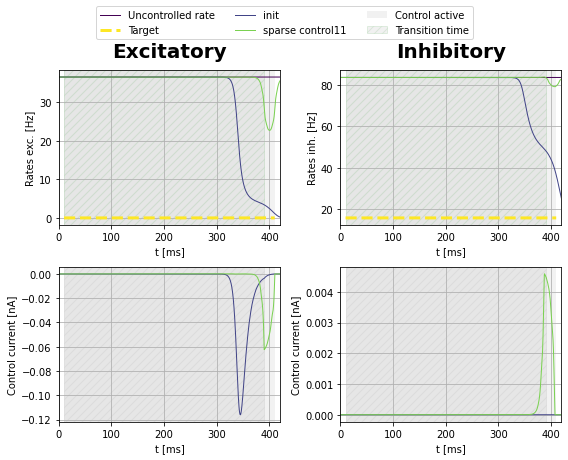

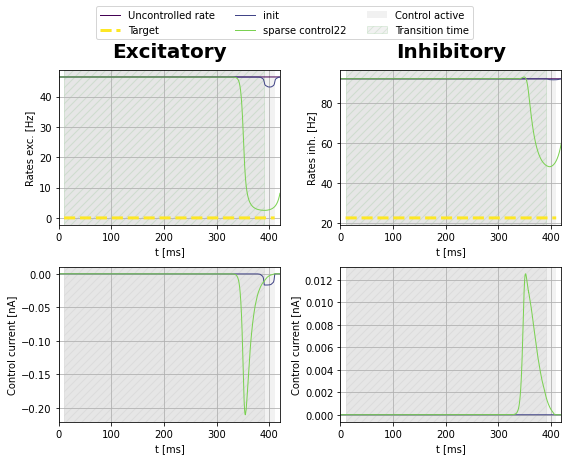

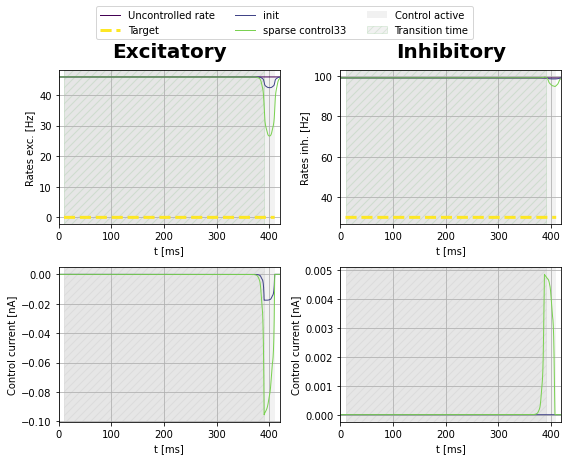

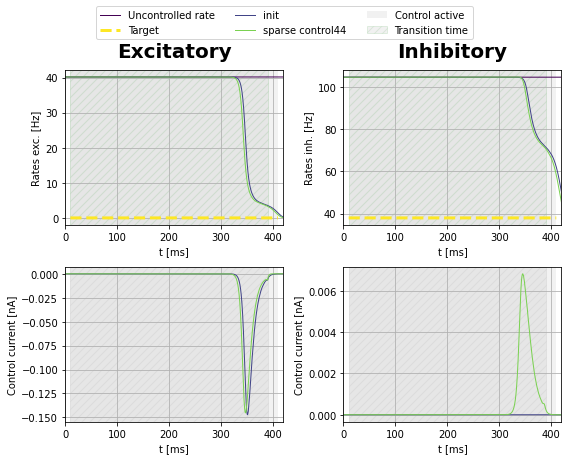

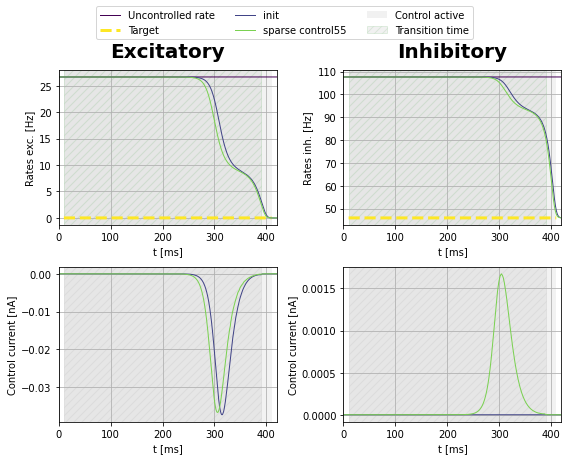

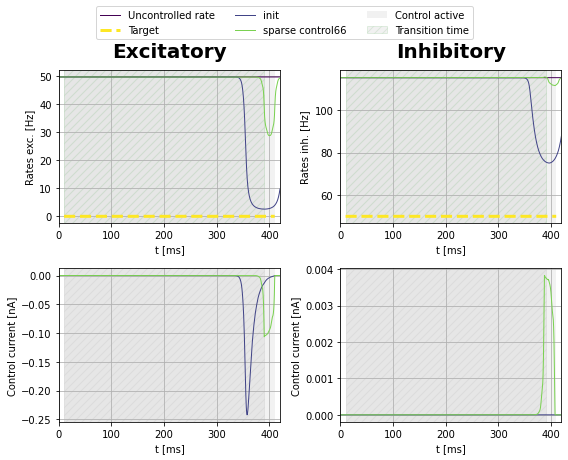

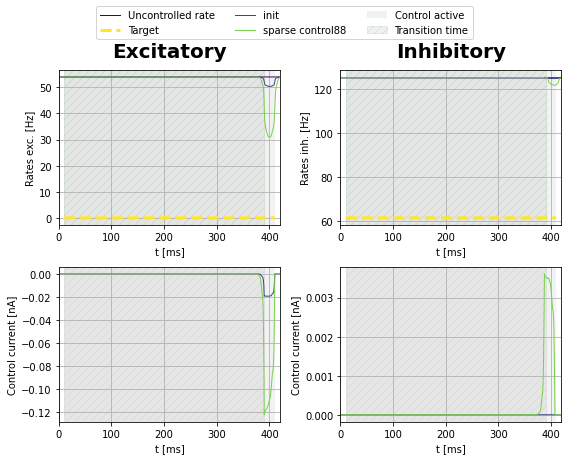

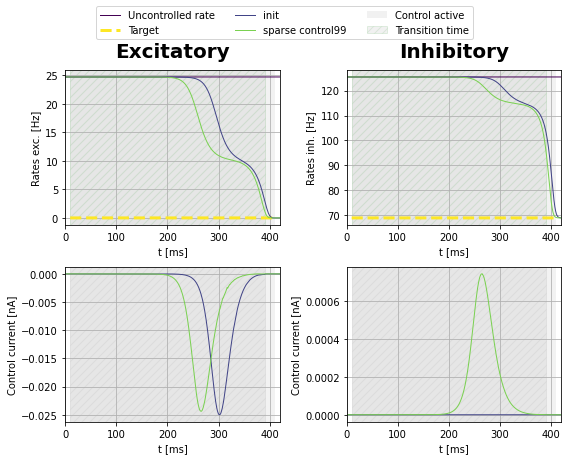

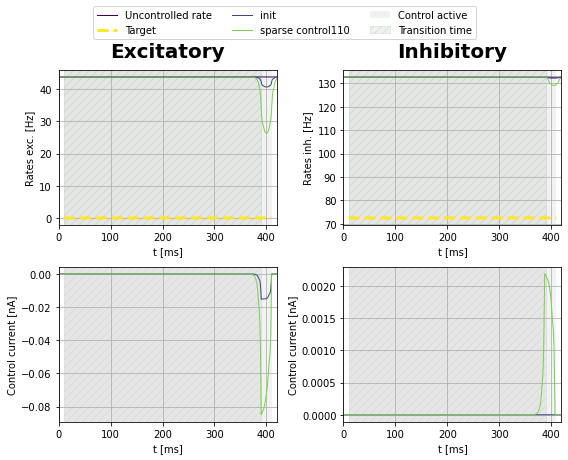

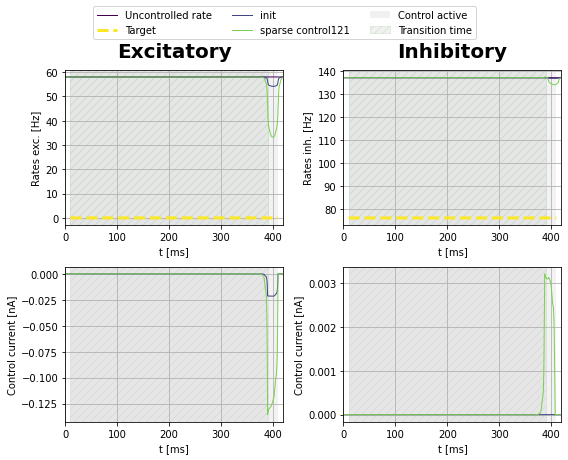

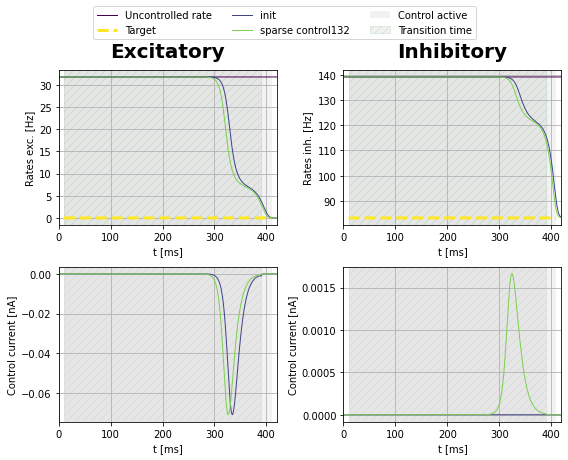

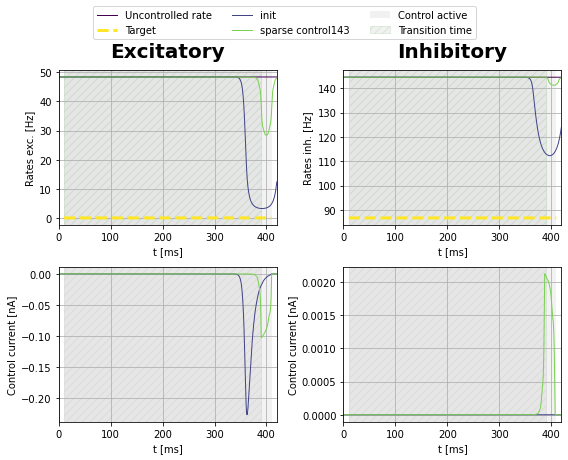

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  7213.456716283832
set cost params:  1.0 7213.456716283832 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10744.973920981958
Gradient descend method:  None
RUN  1 , total integrated cost =  10377.317116042681
RUN  2 , total integrated cost =  10371.769417219402
RUN  3 , total integrated cost =  10371.769251014633
RUN  4 , total integrated cost =  10371.769250880436


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  10371.769250880436
Control only changes marginally.
RUN  5 , total integrated cost =  10371.769250880436
Improved over  5  iterations in  1.3394947089254856  seconds by  3.4732952620085626  percent.
Problem in initial value trasfer:  Vmean_exc -56.6500140612976 -56.65073259790228
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  3301.2791693320046
set cost params:  1.0 3301.2791693320046 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21557.001627351237
Gradient descend method:  None
RUN  1 , total integrated cost =  21556.997286332782
RUN  2 , total integrated cost =  19828.53167297163
RUN  3 , total integrated cost =  14378.793718289004
RUN  4 , total integrated cost =  14265.016410388278
RUN  5 , total integrated cost =  14251.930664723024
RUN  6 , total integrated cost =  14251.930664723015
RUN  7 , total integrated cost =  14251.930664723011


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  14251.930664723011
Control only changes marginally.
RUN  8 , total integrated cost =  14251.930664723011
Improved over  8  iterations in  1.7741168159991503  seconds by  33.88723111362411  percent.
Problem in initial value trasfer:  Vmean_exc -56.66937476923309 -56.67110724434107
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5080.408429023502
set cost params:  1.0 5080.408429023502 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16782.181911505293
Gradient descend method:  None
RUN  1 , total integrated cost =  16022.424017549007
RUN  2 , total integrated cost =  16013.157550472082
RUN  3 , total integrated cost =  16013.136470756948
RUN  4 , total integrated cost =  16013.136470756941


...

RUN  5 , total integrated cost =  19044.700933698503
Control only changes marginally.
RUN  5 , total integrated cost =  19044.700933698503
Improved over  5  iterations in  1.560337234288454  seconds by  8.006194427423452e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.692578189061656 -56.69260940318879
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  120841.17592477688
set cost params:  1.0 120841.17592477688 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33312.982720430104
Gradient descend method:  None
RUN  1 , total integrated cost =  33312.95492962163
RUN  2 , total integrated cost =  33312.95487568343
RUN  3 , total integrated cost =  33312.9548756834


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  33312.9548756834
Control only changes marginally.
RUN  4 , total integrated cost =  33312.9548756834
Improved over  4  iterations in  1.0750241689383984  seconds by  8.358527045970732e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70358212554774 -56.70356986366893
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
no convergence
weight =  141892.39919342843
set cost params:  1.0 141892.39919342843 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23209.108612536864
Gradient descend method:  None
RUN  1 , total integrated cost =  23209.088161104646
RUN  2 , total integrated cost =  23209.088152021897
RUN  3 , total integrated cost =  23209.088152021886


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  23209.088152021886
Control only changes marginally.
RUN  4 , total integrated cost =  23209.088152021886
Improved over  4  iterations in  1.0553696937859058  seconds by  8.815726324939988e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.700231160419904 -56.700253304470266
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [False, False], [False, False], [False, False], [True, True], [True, True], [False, False], [True, True], [False, False], [True, True], [False, False], [False, False], [True, True], [False, False]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13061.485111257496
Gradient descend method:  None
RUN  1 , total integrated cost =  44.77732869515593
RUN  2 , total integrated cost =  34.713628802152684
RUN  3 , total integrated cost =  21.933625184392483
RUN  4 , total integrated cost =  17.870241627080507
RUN  5 , total integrated cost =  13.010473818547744
RUN  6 , total integrated cost =  11.210293489343579
RUN  7 , total integrated cost =  9.567991221684041
RUN  8 , total integrated cost =  8.654816160921223
RUN  9 , total integrated cost =  7.674329395185993
RUN  10 , total integrated cost =  7.128441109950496
RUN  11 , total integrated cost =  6.678136327866953
RUN  12 , total integrated cost =  6.385840337426865
RUN  13 , total integrated cost =  6.16388915238151
RUN  14 , total integrated cost =  5.993964471156303
RUN  15 , total integrated cost =  5.849765557673413
RUN  16

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  344 , total integrated cost =  2.7254662965635
Improved over  344  iterations in  22.24507501721382  seconds by  99.97913356503224  percent.
Problem in initial value trasfer:  Vmean_exc -66.01845662882151 -66.02088041647542
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21154.15518785991
Gradient descend method:  None
RUN  1 , total integrated cost =  90.43896499328737
RUN  2 , total integrated cost =  64.5800816736636
RUN  3 , total integrated cost =  36.139421803200015
RUN  4 , total integrated cost =  29.34970586630164
RUN  5 , total integrated cost =  22.634751264432268
RUN  6 , total integrated cost =  20.183038353884815
RUN  7 , total integrated cost =  17.970431624145313
RUN  8 , total integrated cost =  16.79522026488018
RUN  9 , total integrated cost =  15.743624656788246
RUN  10 , total integrated cost =  15.075840401381527
RUN  11 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  324 , total integrated cost =  7.027974709240734
Improved over  324  iterations in  20.737135717645288  seconds by  99.96677733217503  percent.
Problem in initial value trasfer:  Vmean_exc -65.12035844883727 -65.12491281900617
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20671.140904058957
Gradient descend method:  None
RUN  1 , total integrated cost =  87.09125288797229
RUN  2 , total integrated cost =  63.60645046580664
RUN  3 , total integrated cost =  36.48536450041556
RUN  4 , total integrated cost =  30.23797792710385
RUN  5 , total integrated cost =  23.12673416982268
RUN  6 , total integrated cost =  20.361333975770087
RUN  7 , total integrated cost =  17.92127242540925
RUN  8 , total integrated cost =  16.69049623665974
RUN  9 , total integrated cost =  15.499558048621981
RUN  10 , total integrated cost =  14.782090098151052
RUN  11 ,

...

Control only changes marginally.
RUN  283 , total integrated cost =  14.28545277199346
Improved over  283  iterations in  18.231909541413188  seconds by  99.95670494013731  percent.
Problem in initial value trasfer:  Vmean_exc -65.20220369547592 -65.2148099815801
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19.72730412762161
Gradient descend method:  None
RUN  1 , total integrated cost =  1.22946010386675
RUN  2 , total integrated cost =  1.2292826486696398
RUN  3 , total integrated cost =  1.2292824638131459
RUN  4 , total integrated cost =  1.229282459708348
RUN  5 , total integrated cost =  1.2292824597083476


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  1.2292824597083452
RUN  7 , total integrated cost =  1.2292824597083447
RUN  8 , total integrated cost =  1.2292824597083447
Control only changes marginally.
RUN  8 , total integrated cost =  1.2292824597083447
Improved over  8  iterations in  0.663763714954257  seconds by  93.76862417816564  percent.
Problem in initial value trasfer:  Vmean_exc -74.3281265188974 -74.35964299870248
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22987.86006400518
Gradient descend method:  None
RUN  1 , total integrated cost =  99.3588403588803
RUN  2 , total integrated cost =  78.98614477805539
RUN  3 , total integrated cost =  17.625536426941025
RUN  4 , total integrated cost =  16.83771172395701
RUN  5 , total integrated cost =  16.076360062299358
RUN  6 , total integrated cost =  15.512356454162568
RUN  7 , total integrated cost =  14.95997104766042
RUN  8 , tota

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  339 , total integrated cost =  7.504237366616569
Improved over  339  iterations in  21.652821235358715  seconds by  99.96735565056633  percent.
Problem in initial value trasfer:  Vmean_exc -68.86319774789833 -68.88657475159505


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.7254662965635
Gradient descend method:  None
RUN  1 , total integrated cost =  2.7254662965635
Control only changes marginally.
RUN  1 , total integrated cost =  2.7254662965635
Improved over  1  iterations in  0.16001884639263153  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.01845662882151 -66.02088041647542
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.027974709240734
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.027974709240734
Control only changes marginally.
RUN  1 , total integrated cost =  7.027974709240734
Improved over  1  iterations in  0.16025937721133232  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.12035844883727 -65.12491281900617
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.5630382470142274
Gradient descend method:  None
RUN  1 , total integrated cost =  6.5630382470142274
Control only changes marginally.
RUN  1 , total integrated cost =  6.5630382470142274
Improved over  1  iterations in  0.15916914865374565  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.70098806237343 -66.71276559191278
-------  44 0.47500000000000014 0.5750000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.78827409809

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  0.2515882067326633
Control only changes marginally.
RUN  1 , total integrated cost =  0.2515882067326633
Improved over  1  iterations in  0.1542053073644638  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -76.27642229998997 -76.30610330711615
-------  110 0.5000000000000002 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.1637316296632365
Gradient descend method:  None
RUN  1 , total integrated cost =  5.1637316296632365
Control only changes marginally.
RUN  1 , total integrated cost =  5.1637316296632365
Improved over  1  iterations in  0.16001515462994576  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.21056552615994 -70.23535420902378
-------  121 0.5750000000000002 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.28545277

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14.28545277199346
Control only changes marginally.
RUN  1 , total integrated cost =  14.28545277199346
Improved over  1  iterations in  0.16218065097928047  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.20220369547592 -65.2148099815801
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.2292824597083447
Gradient descend method:  None
RUN  1 , total integrated cost =  1.2292824597083447
Control only changes marginally.
RUN  1 , total integrated cost =  1.2292824597083447
Improved over  1  iterations in  0.1581391841173172  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -74.3281265188974 -74.35964299870248
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.5042373666165

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.504237366616569
Control only changes marginally.
RUN  1 , total integrated cost =  7.504237366616569
Improved over  1  iterations in  0.15847895666956902  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -68.86319774789833 -68.88657475159505
--------------- 12
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004


In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
